In [46]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [47]:
# Define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str


In [48]:
def calculate_BMI(state:BMIState)->BMIState:
    weight=state['weight_kg']
    height=state['height_m']
    bmi=weight/(height**2)

    state['bmi']=round(bmi,2)

    return state

def bmi_label(state: BMIState)->BMIState:
    bmi_val=state['bmi']

    if bmi_val<18.5:
        state['category']='Underweight'
    elif 18.5 <= bmi_val < 25:
        state['category']='Normal'
    else:
        state['category']='Overweight'

    return state

In [49]:
# Defining Graph
graph = StateGraph(BMIState)

# Nodes
graph.add_node('calculate_BMI',calculate_BMI)
graph.add_node('bmi_label', bmi_label)

# Edges
graph.add_edge(START, 'calculate_BMI')
graph.add_edge('calculate_BMI', 'bmi_label')
graph.add_edge('bmi_label',END)

# Compiling
workflow= graph.compile()

In [54]:
# execute
initial_state={'weight_kg':60,'height_m':1.70}
final_state=workflow.invoke(initial_state)

print(final_state)


{'weight_kg': 60, 'height_m': 1.7, 'bmi': 20.76, 'category': 'Normal'}


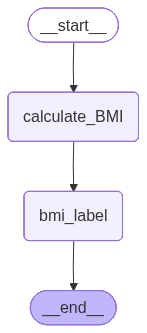

In [51]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())